<a href="https://colab.research.google.com/github/ckrickyh/pythonTools/blob/main/K_means_clustering_for_tree_survey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

# URL to the Google Sheet in CSV format
url = "https://docs.google.com/spreadsheets/d/1Dq9VCs1tcabKRQeNpEs_vz6n5bmYWXrX9N59O6ldFL/gviz/tq?tqx=out:csv"

# Read the CSV data into a DataFrame
dfRaw = pd.read_csv(url)

dfRaw.columns.tolist()
df = dfRaw[['Tree No.', 'X coordinates', 'Y coordinates']]
df = df[~df['X coordinates'].isna()]
df

,Tree No.,X coordinates,Y coordinates
6,AT250,828181.380,840473.250
8,T1269,828970.123,840360.232
9,T1270,828968.345,840360.957
10,T1271,828966.794,840360.543
11,T1272,828966.485,840360.660
...,...,...,...
504,TG40B-T0032,830156.010,840315.040
505,TG40B-T0033,830150.650,840314.520
506,TG40B-T0034,830150.410,840316.400
507,TG40C-T0020,830337.650,840304.370


# kmeans clustering

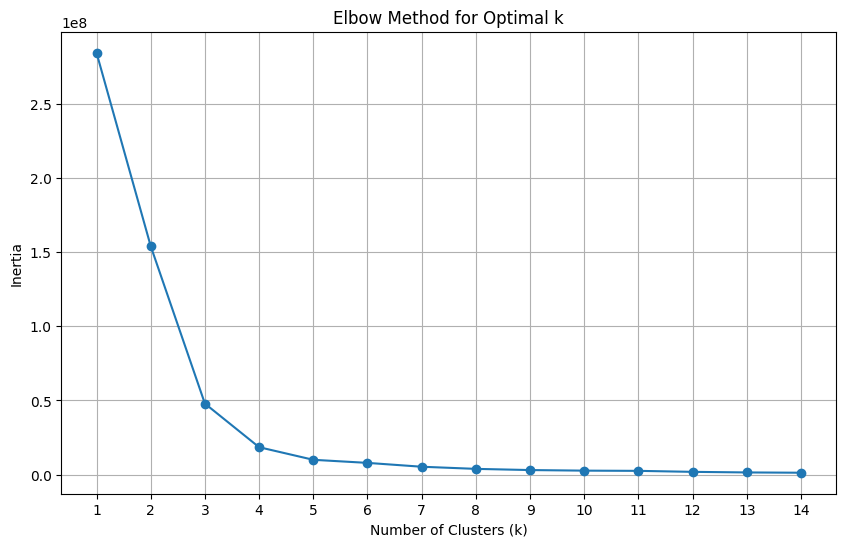

In [3]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


# Elbow Method to find optimal number of clusters
inertia = []
k_values = range(1, 15)  # Test for k from 1 to 15

for k in k_values:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df[['X coordinates', 'Y coordinates']])
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid()
plt.show()

        Tree No.  X coordinates  Y coordinates  tree_group
6          AT250     828181.380     840473.250           2
8          T1269     828970.123     840360.232           4
9          T1270     828968.345     840360.957           4
10         T1271     828966.794     840360.543           4
11         T1272     828966.485     840360.660           4
..           ...            ...            ...         ...
504  TG40B-T0032     830156.010     840315.040           6
505  TG40B-T0033     830150.650     840314.520           6
506  TG40B-T0034     830150.410     840316.400           6
507  TG40C-T0020     830337.650     840304.370           6
508  TG40C-T0021     830255.198     840318.698           6

[502 rows x 4 columns]


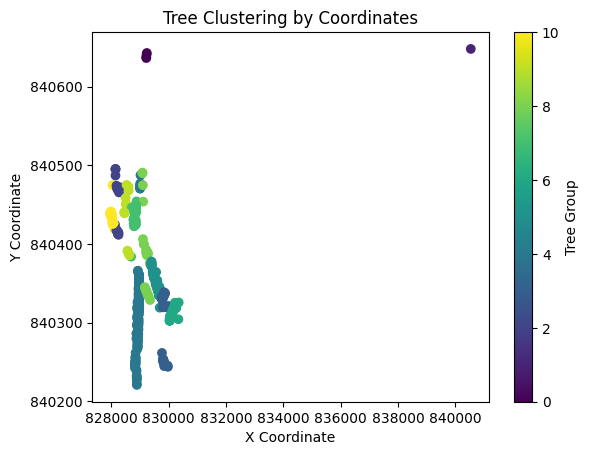

In [4]:
# Choose the optimal number of clusters based on the Elbow plot
optimal_k = 11  # Replace this value based on the Elbow plot observation


# Apply KMeans clustering with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k)
df['tree_group'] = kmeans.fit_predict(df[['X coordinates', 'Y coordinates']])

# Display the DataFrame with tree group
print(df)

# Optional: Visualize the clusters
plt.scatter(df['X coordinates'], df['Y coordinates'], c=df['tree_group'], cmap='viridis')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Tree Clustering by Coordinates')
plt.colorbar(label='Tree Group')
plt.show()

# same-size kmeans clustering

In [5]:
!pip install k-means-constrained

constrained_cluster
7    52
8    50
6    50
1    50
0    50
9    50
4    50
3    50
2    50
5    50
Name: count, dtype: int64


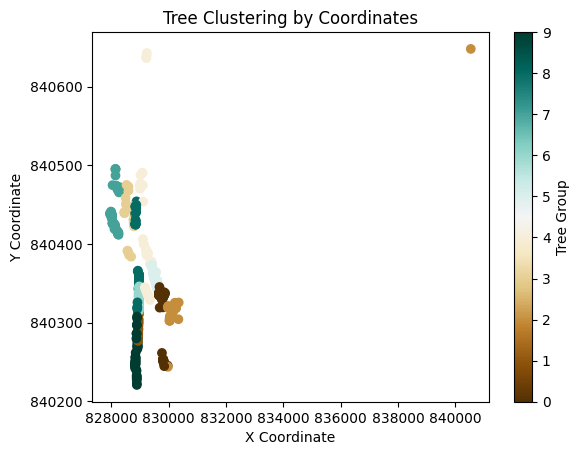

In [23]:
from k_means_constrained import KMeansConstrained

treeGpSize = 50
# Define parameters
n_clusters = df.shape[0] // treeGpSize
min_points_per_cluster = treeGpSize

# Create a KMeansConstrained instance
kmeans = KMeansConstrained(
    n_clusters=n_clusters,
    size_min=min_points_per_cluster,  # Minimum size for each cluster
    random_state=103
)

# Fit the model to the data
kmeans.fit(df[['X coordinates', 'Y coordinates']])

# Assign cluster labels to the DataFrame
df['constrained_cluster'] = kmeans.labels_


# Optional: Count points in each cluster
cluster_counts = df['constrained_cluster'].value_counts()
print(cluster_counts)

plt.scatter(df['X coordinates'], df['Y coordinates'], c=df['constrained_cluster'], cmap='BrBG')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Tree Clustering by Coordinates')
plt.colorbar(label='Tree Group')
plt.show()

In [22]:
df

,Tree No.,X coordinates,Y coordinates,tree_group,constrained_cluster
6,AT250,828181.380,840473.250,2,7
8,T1269,828970.123,840360.232,4,8
9,T1270,828968.345,840360.957,4,8
10,T1271,828966.794,840360.543,4,8
11,T1272,828966.485,840360.660,4,8
...,...,...,...,...,...
504,TG40B-T0032,830156.010,840315.040,6,2
505,TG40B-T0033,830150.650,840314.520,6,2
506,TG40B-T0034,830150.410,840316.400,6,2
507,TG40C-T0020,830337.650,840304.370,6,2
